<a href="https://colab.research.google.com/github/Sonuit22/ProjectSA/blob/main/CNN%2BBiLSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow -q

In [2]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [3]:
df = pd.read_csv("/content/Tweets.csv")

df = df[["airline_sentiment","text"]]
df.columns = ["sentiment","text"]

df.head()

,sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials t...
2,neutral,@VirginAmerica I didn't today... Must mean I n...
3,negative,@VirginAmerica it's really aggressive to blast...
4,negative,@VirginAmerica and it's a really big bad thing...


In [5]:
df = df[df["sentiment"].isin(["positive","negative"])]

In [6]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

df["clean_text"] = df["text"].apply(clean_text)

/tmp/ipykernel_4719/3942246259.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["clean_text"] = df["text"].apply(clean_text)


In [7]:
encoder = LabelEncoder()
df["label"] = encoder.fit_transform(df["sentiment"])

df["label"].value_counts()

/tmp/ipykernel_4719/748459051.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["label"] = encoder.fit_transform(df["sentiment"])


,count
label,
0,9178
1,2363


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.2,
    random_state=42
)

In [9]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [10]:
max_length = 100

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post')

Build CNN + BiLSTM Model

In [11]:
model = Sequential()

# Embedding layer
model.add(Embedding(input_dim=5000, output_dim=128, input_length=max_length))

# CNN layer
model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))

# Pooling
model.add(MaxPooling1D(pool_size=2))

# BiLSTM layer
model.add(Bidirectional(LSTM(64)))

# Dropout
model.add(Dropout(0.5))

# Output layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Compile Model

In [12]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Train Model

In [13]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/5
289/289 ━━━━━━━━━━━━━━━━━━━━ 39s 113ms/step - accuracy: 0.8748 - loss: 0.3012 - val_accuracy: 0.9216 - val_loss: 0.2124
Epoch 2/5
289/289 ━━━━━━━━━━━━━━━━━━━━ 33s 116ms/step - accuracy: 0.9472 - loss: 0.1425 - val_accuracy: 0.9225 - val_loss: 0.2230
Epoch 3/5
289/289 ━━━━━━━━━━━━━━━━━━━━ 40s 112ms/step - accuracy: 0.9701 - loss: 0.0859 - val_accuracy: 0.9190 - val_loss: 0.2729
Epoch 4/5
289/289 ━━━━━━━━━━━━━━━━━━━━ 31s 109ms/step - accuracy: 0.9822 - loss: 0.0524 - val_accuracy: 0.9134 - val_loss: 0.2994
Epoch 5/5
289/289 ━━━━━━━━━━━━━━━━━━━━ 32s 112ms/step - accuracy: 0.9899 - loss: 0.0303 - val_accuracy: 0.9117 - val_loss: 0.3538


In [14]:
loss, accuracy = model.evaluate(X_test_pad, y_test)

print("Accuracy:", accuracy)

73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9117 - loss: 0.3538
Accuracy: 0.9116500616073608


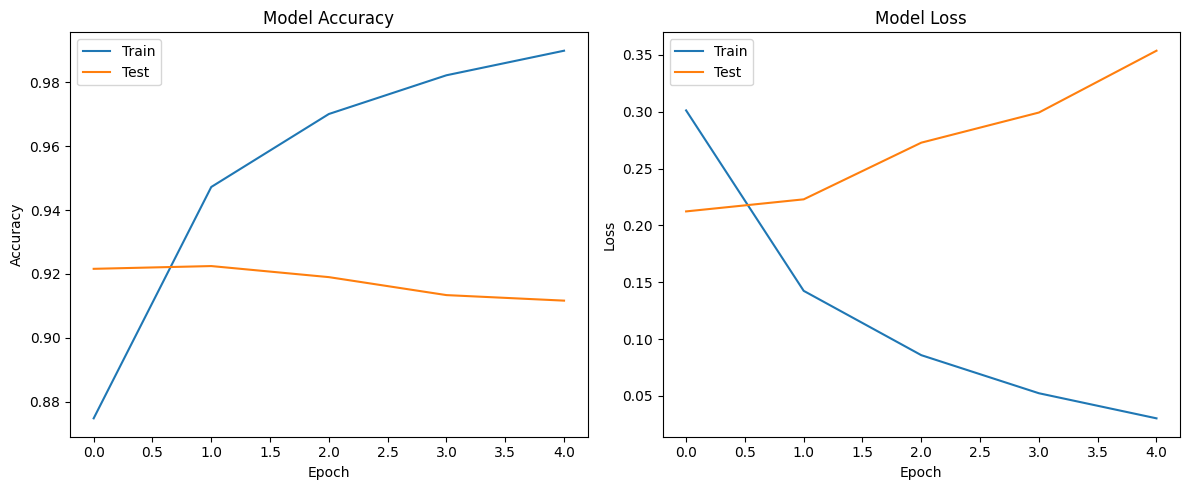

In [15]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.tight_layout()
plt.show()

In [16]:
def predict_sentiment(text):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_length, padding='post')

    pred = model.predict(pad)[0][0]

    return "positive" if pred > 0.5 else "negative"

In [17]:
print(predict_sentiment("The flight was terrible"))
print(predict_sentiment("Amazing service and smooth flight"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
positive


In [18]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# Define an improved model structure
model_improved = Sequential([
    Embedding(input_dim=5000, output_dim=128),

    # Increased filters and added Batch Normalization
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)), # Stacked LSTM

    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_improved.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Early stopping prevents overfitting by monitoring validation loss
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

print("Improved model architecture created with stacking and normalization.")

Improved model architecture created with stacking and normalization.


In [19]:
history_improved = model_improved.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_pad, y_test),
    callbacks=[early_stop]
)

Epoch 1/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 53s 151ms/step - accuracy: 0.8801 - loss: 0.3015 - val_accuracy: 0.9147 - val_loss: 0.2355
Epoch 2/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 42s 144ms/step - accuracy: 0.9532 - loss: 0.1332 - val_accuracy: 0.9246 - val_loss: 0.2171
Epoch 3/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 42s 147ms/step - accuracy: 0.9776 - loss: 0.0699 - val_accuracy: 0.9078 - val_loss: 0.2696
Epoch 4/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 79s 138ms/step - accuracy: 0.9880 - loss: 0.0384 - val_accuracy: 0.9199 - val_loss: 0.3722


In [20]:
def predict_sentiment_improved(text):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_length, padding='post')

    pred = model_improved.predict(pad, verbose=0)[0][0]

    sentiment = "positive" if pred > 0.5 else "negative"
    print(f"Text: {text}")
    print(f"Prediction: {sentiment} ({pred:.4f})")
    return sentiment

# Testing with example sentences
predict_sentiment_improved("The flight was terrible")
predict_sentiment_improved("Amazing service and smooth flight")
predict_sentiment_improved("It was okay, but the food could be better")

Text: the flight was terrible
Prediction: negative (0.0402)
Text: amazing service and smooth flight
Prediction: positive (0.9173)
Text: it was okay but the food could be better
Prediction: negative (0.1347)


'negative'